In [1]:
### Imports and setup
import numpy as np
import glob
import os
import sys
!pip install imexam

import astropy
from astropy.io import fits
from astropy.modeling.models import Polynomial1D,Chebyshev1D,Legendre1D,Hermite1D, Gaussian1D,Gaussian2D,Polynomial2D
from astropy.modeling import fitting
from astropy.stats import mad_std
from astropy.nddata import CCDData, StdDevUncertainty
from astropy import units as u
from astropy.stats import sigma_clipped_stats
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.visualization import hist
from astropy.stats import sigma_clip
from astropy.time import Time

from datetime import datetime

import photutils
from photutils.aperture import CircularAperture,CircularAnnulus
from photutils.aperture import aperture_photometry
from photutils.detection import DAOStarFinder
from imexam.imexamine import Imexamine
from imexam import math_helper

from ccdproc import ImageFileCollection
import ccdproc as ccdp

import scipy
from scipy import stats
from scipy.optimize import curve_fit

from matplotlib import pyplot as plt
from matplotlib import rc
%matplotlib inline

phot_func_dir = '/Users/brigitwp/Downloads/astr_8060_s26/Software/py/ccd-reduction-and-photometry-guide/ccd-reduction-and-photometry-guide/notebooks/'
sys.path.insert(0,phot_func_dir)
from convenience_functions import show_image

plt.style.use('/Users/brigitwp/Downloads/astr_8060_s26/Software/py/ccd-reduction-and-photometry-guide/ccd-reduction-and-photometry-guide/notebooks/guide.mplstyle')
#rc('font', size=20)
rc('axes', grid=False)

Ginga not installed, use other viewer, or no viewer


In [2]:
### Data Directories Needed
data_dir = '/Users/brigitwp/Downloads/astr_8060_s26/Imaging/'            # raw data
PG_data_dir = "/Users/brigitwp/Downloads/astr_8060_s26/reduced_data/hw5/PG_flat_corr/" #PG data flat corrected & otz 
NGC_data_dir = "/Users/brigitwp/Downloads/astr_8060_s26/reduced_data/hw5/NGC_flat_corr/" #NGC data flat corrected & otz 

1. CCDs are ideal because over the available dynamic range, they are very linear (that is,
one photon produces on electron).Test the linearity of the CCD using the sequence of
exposures labeled linearity test in the log. Make a plot of ADU versus time and determine
whether the chip is linear to the full 16 bits of the A-D converter. What you care about
here is whether the signal stays linear with exposure time as the flux in the peak pixel
approaches the 216 ADU limit.

In [3]:
### All(ish) image files
img_files = glob.glob(data_dir+'a[0-1]*.fits')
sort = np.sort(img_files)

##lin test
lin_id = range(73,80)
lin_V = sort[lin_id]

hdu = fits.open(lin_V[4])
hdr = hdu[0].header

The slope is 6.205538962813418
The intercept is 664.8275862083444


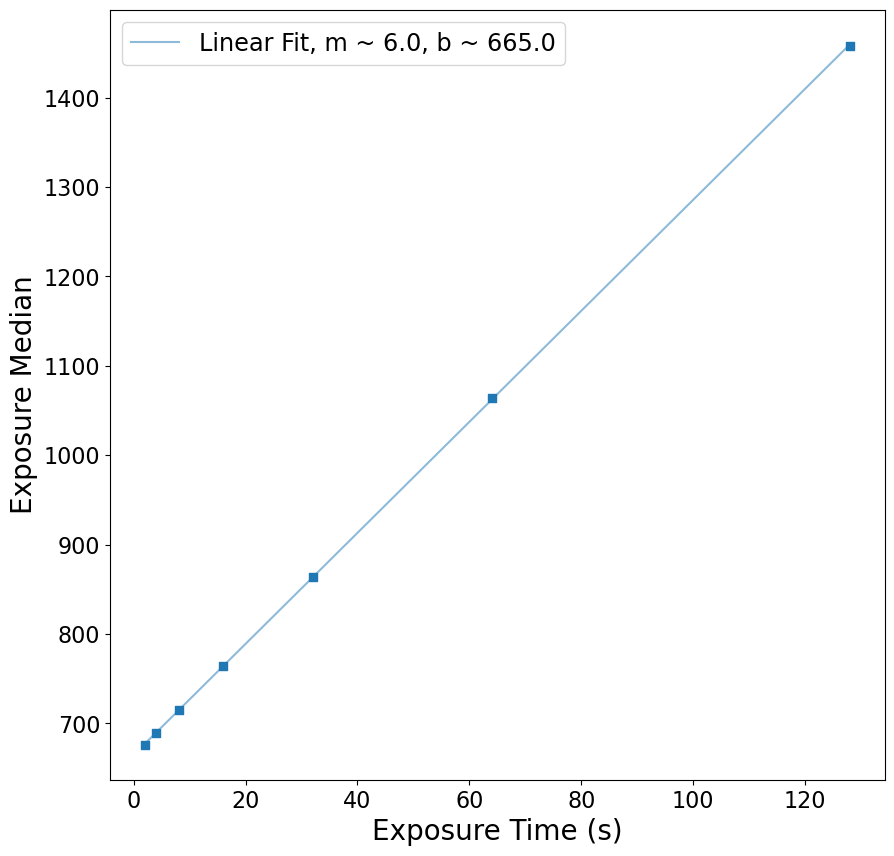

In [4]:
### Grab the medians and exposure times
med_list = []
ET_list = []

## Get the median pixels and exposure times into lists
for i in lin_V:
    hdu = fits.open(i)
    hdr = hdu[0].header
    dat = hdu[0].data

    hdr_ET = hdr['EXPTIME']
    ET_list.append(hdr_ET)
    
    pix_med = np.median(dat)
    med_list.append(pix_med)

## Define a linear model for scipy optimize to fit
def lin_model(m,x,b): 
    return m*x + b

## Pull params and print
params, covariance = curve_fit(lin_model, ET_list, med_list)
m,b = params
print("The slope is " + str(m))
print("The intercept is " + str(b))

## Plot linear fit over the data
x_fit = np.linspace(min(ET_list), max(ET_list), 50)
y_fit = m * x_fit + b

## Plot
plt.scatter(ET_list, med_list, marker = "s")
plt.plot(x_fit, y_fit, alpha = 0.5, label = "Linear Fit, m ~ " + str(np.round(m)) + ', b ~ ' + str(np.round(b)))
plt.xlabel("Exposure Time (s)")
plt.ylabel("Exposure Median")
plt.legend()

2. Use photutils to perform aperture photometry on three (non saturated) stars in the
PG1633+099 standard field: a really faint one, a medium bright one, and a bright one.
Perform aperture photometry using at least 5 aperture sizes from very small to very large
and make a plot that reproduces the one from Howell Figure 5.7 showing S/N as a function
of aperture radius. What is a good aperture size to use for this dataset?

In [5]:
### Load PG Data
PG_zot_glob = np.sort(glob.glob(PG_data_dir+'*.fits'))
PG_Grp1_U = fits.getdata(PG_zot_glob[1])
PG_Grp1_B = fits.getdata(PG_zot_glob[2])
#PG_Grp1_V = fits.getdata(PG_zot_glob[])
PG_Grp1_R = fits.getdata(PG_zot_glob[4])
PG_Grp1_I = fits.getdata(PG_zot_glob[6])

PG_Grp2_U = fits.getdata(PG_zot_glob[8])
PG_Grp2_B = fits.getdata(PG_zot_glob[10])
#PG_Grp2_V = fits.getdata(PG_zot_glob[])
PG_Grp2_R = fits.getdata(PG_zot_glob[12])
PG_Grp2_I = fits.getdata(PG_zot_glob[14])

PG_Grp3_U = fits.getdata(PG_zot_glob[16])
PG_Grp3_B = fits.getdata(PG_zot_glob[18])
#PG_Grp3_V = fits.getdata(PG_zot_glob[])
PG_Grp3_R = fits.getdata(PG_zot_glob[20])
PG_Grp3_I = fits.getdata(PG_zot_glob[22])

## Choose 3 stars
#faint
x1 = 969.58603
y1 = 1201.4585
#medium bright
x2 = 1294.0357
y2 = 835.0953
#bright
x3 = 466.50533
y3 = 596.72852

positions = [(x1,y1),(x2,y2),(x3,y3)]

In [6]:
### Apertures
tiny_aperture = CircularAperture(positions, r=2.0)
tiny_annulus = CircularAnnulus(positions, r_in = 5.0, r_out = 10.0)

very_small_aperture = CircularAperture(positions, r=4.0)
very_small_annulus = CircularAnnulus(positions, r_in = 10.0, r_out = 15.0)

small_aperture = CircularAperture(positions, r=8.0)
small_annulus = CircularAnnulus(positions, r_in = 15.0, r_out = 20.0)

medium_aperture = CircularAperture(positions, r=16.0)
medium_annulus = CircularAnnulus(positions, r_in = 20.0, r_out = 25.0)

large_aperture = CircularAperture(positions, r=32.0)
large_annulus = CircularAnnulus(positions, r_in = 35.0, r_out = 40.0)

very_large_aperture = CircularAperture(positions, r=64.0)
very_large_annulus = CircularAnnulus(positions, r_in = 65.0, r_out = 70.0)

## Make them one object for my own sanity
apers = tiny_aperture, very_small_aperture, small_aperture, medium_aperture, large_aperture, very_large_aperture
annuls = tiny_annulus, very_small_annulus, small_annulus, medium_annulus, large_annulus, very_large_annulus

Text(0.5, 1.0, 'Faint Star')

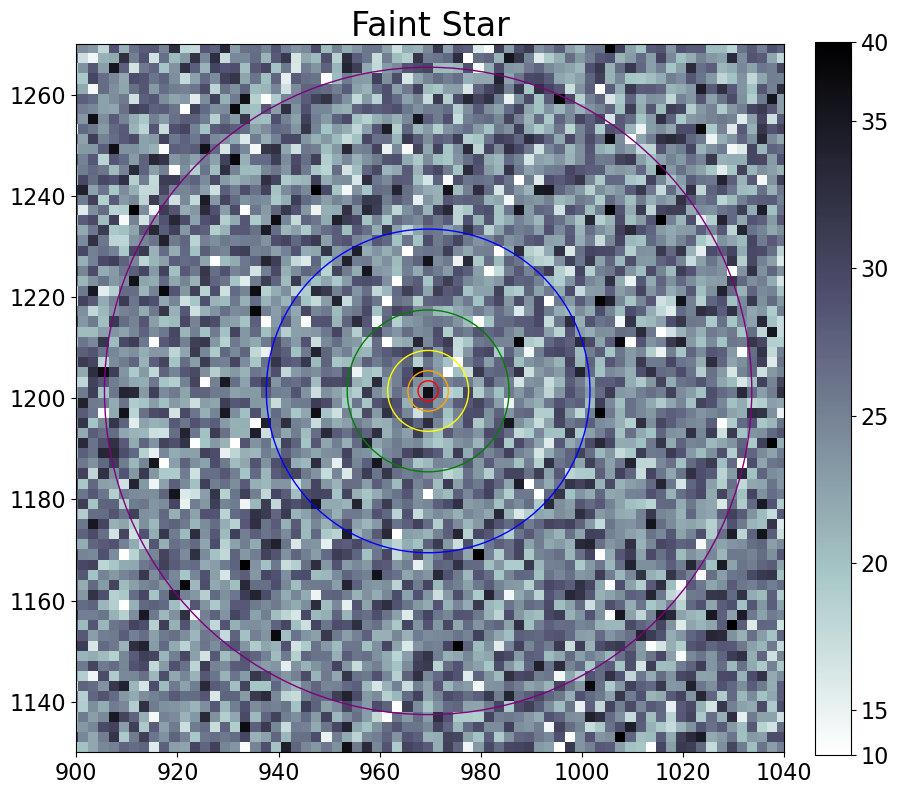

In [7]:
show_image(PG_Grp1_U, cmap = "bone_r")
tiny_aperture.plot(color = 'Red')
very_small_aperture.plot(color = 'Orange')
small_aperture.plot(color = 'Yellow')
medium_aperture.plot(color = 'Green')
large_aperture.plot(color = 'Blue')
very_large_aperture.plot(color = 'Purple')
plt.xlim(900, 1040)
plt.ylim(1130, 1270)
plt.title("Faint Star")

Text(0.5, 1.0, 'Medium Star')

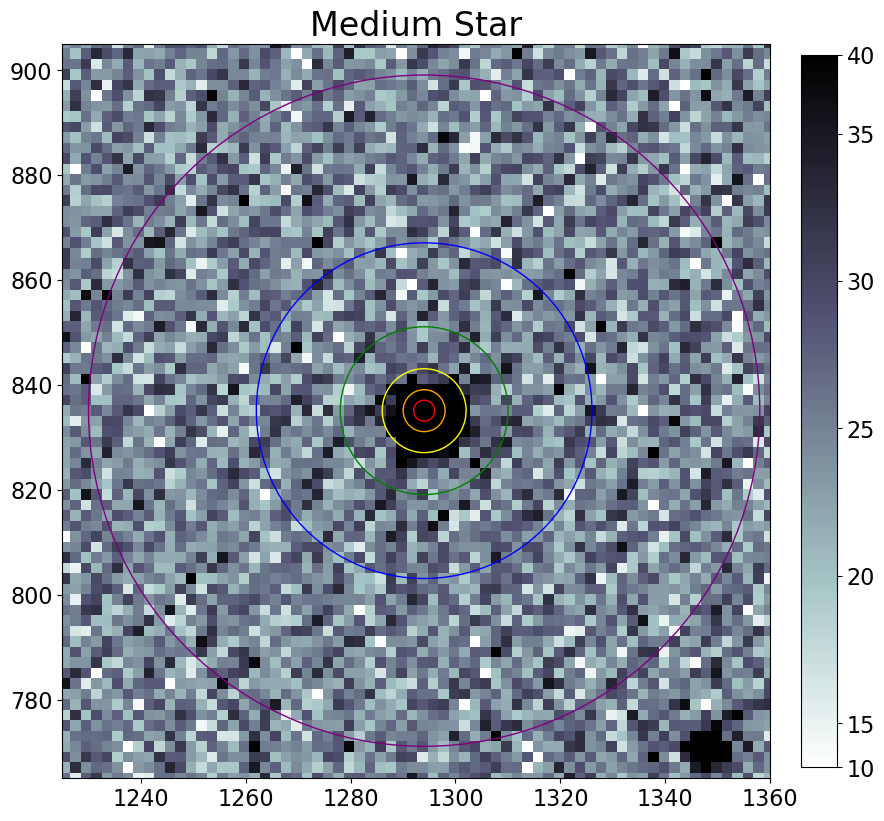

In [8]:
show_image(PG_Grp1_U, cmap = "bone_r")
tiny_aperture.plot(color = 'Red')
very_small_aperture.plot(color = 'Orange')
small_aperture.plot(color = 'Yellow')
medium_aperture.plot(color = 'Green')
large_aperture.plot(color = 'Blue')
very_large_aperture.plot(color = 'Purple')
plt.xlim(1225, 1360)
plt.ylim(765, 905)
plt.title("Medium Star")

Text(0.5, 1.0, 'Bright Star')

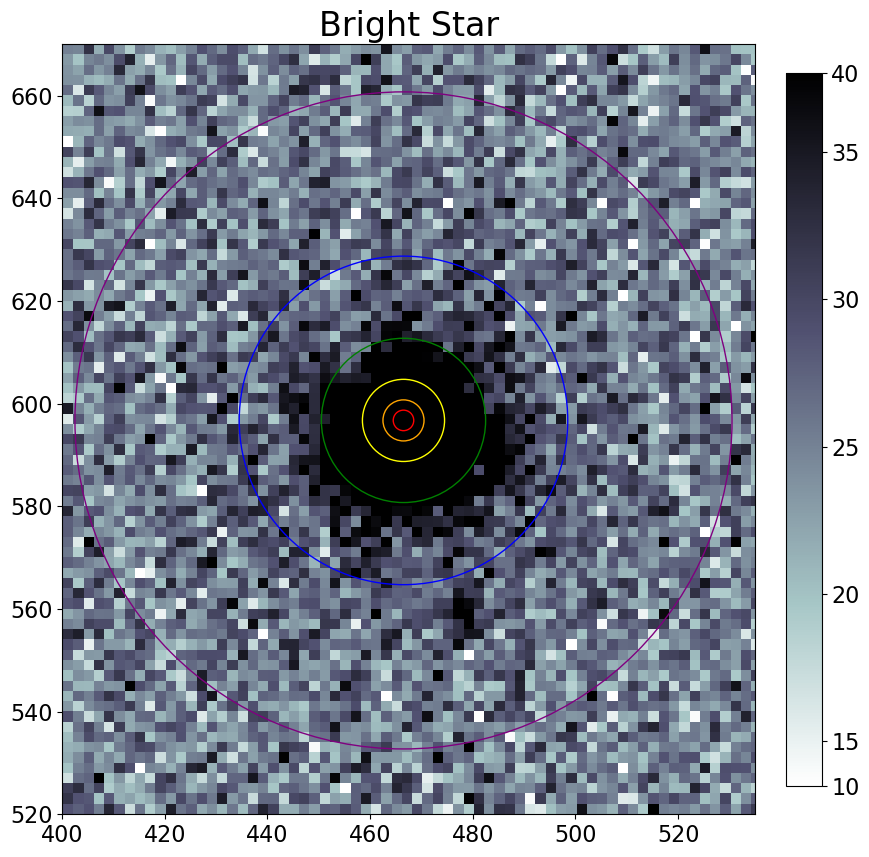

In [9]:
show_image(PG_Grp1_U, cmap = "bone_r")
tiny_aperture.plot(color = 'Red')
very_small_aperture.plot(color = 'Orange')
small_aperture.plot(color = 'Yellow')
medium_aperture.plot(color = 'Green')
large_aperture.plot(color = 'Blue')
very_large_aperture.plot(color = 'Purple')
plt.xlim(400, 535)
plt.ylim(520, 670)
plt.title("Bright Star")

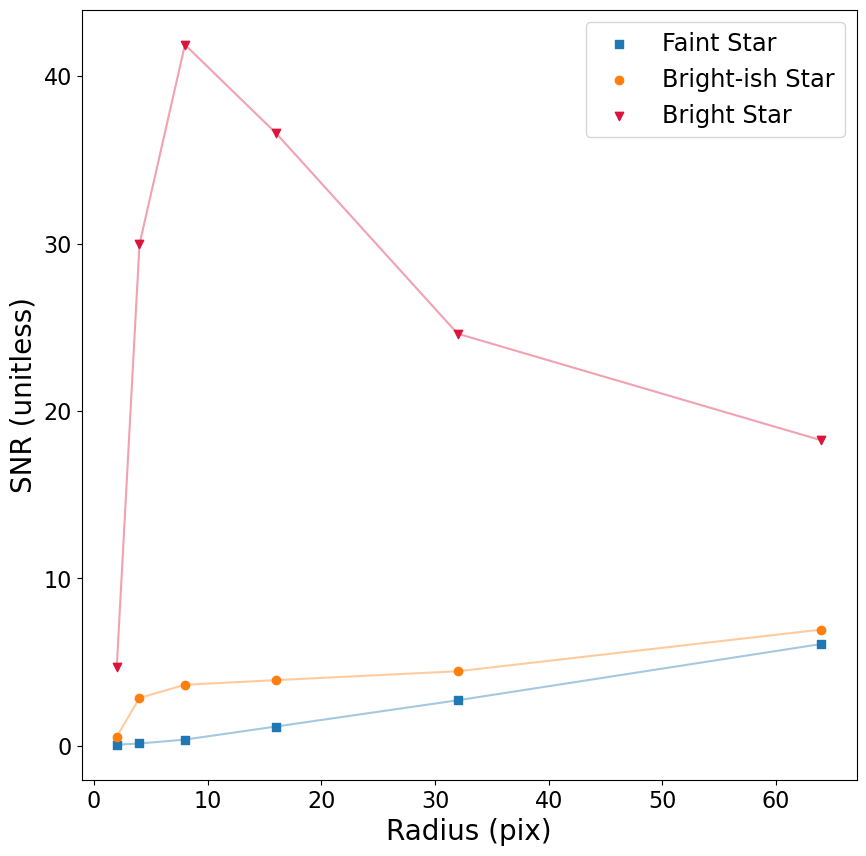

In [10]:
def Howel_SNR(pg_dat, apers=apers, annus=annuls):
    ### Aperture Photometry
    photometry_tab_aper = aperture_photometry(pg_dat, apers)
    photometry_tab_annu = aperture_photometry(pg_dat, annuls)

    ## Get rid of unnecessary columns and rename for clarity
    aper_phot_dat = photometry_tab_aper[photometry_tab_aper.colnames[photometry_tab_aper.colnames.index('aperture_sum_0'):]]
    aper_phot_dat.rename_columns(['aperture_sum_0', 'aperture_sum_1','aperture_sum_2','aperture_sum_3','aperture_sum_4','aperture_sum_5'], ['tiny', 'very_small', 'small', 'medium', 'large', 'very_large'])

    annu_phot_dat = photometry_tab_annu[photometry_tab_annu.colnames[photometry_tab_annu.colnames.index('aperture_sum_0'):]]
    annu_phot_dat.rename_columns(['aperture_sum_0', 'aperture_sum_1','aperture_sum_2','aperture_sum_3','aperture_sum_4','aperture_sum_5'], ['tiny', 'very_small', 'small', 'medium', 'large', 'very_large'])

    ## Row data into divisible arrays
    faint_apers = np.array(list(aper_phot_dat[0]))
    faint_annuls = np.array(list(annu_phot_dat[0]))

    brightish_apers = np.array(list(aper_phot_dat[1]))
    brightish_annu = np.array(list(annu_phot_dat[1]))

    bright_apers = np.array(list(aper_phot_dat[2]))
    bright_annu = np.array(list(annu_phot_dat[2]))

    ## Take SNRs with aper/annu
    faint_SNR = faint_apers/faint_annuls
    brightish_SNR = brightish_apers/brightish_annu
    bright_SNR = bright_apers/brightish_annu

    ## List radii
    radii = np.array([2, 4, 8, 16, 32, 64])

    ## Plot!!
    plt.plot(radii,faint_SNR, alpha = 0.4)
    plt.scatter(radii,faint_SNR, marker = 's', label = "Faint Star")
    plt.plot(radii,brightish_SNR, alpha = 0.4)
    plt.scatter(radii,brightish_SNR, label = "Bright-ish Star")
    plt.plot(radii,bright_SNR, alpha = 0.4, color = "crimson")
    plt.scatter(radii,bright_SNR,  marker = 'v', label = "Bright Star", color = "crimson")
    plt.xlabel("Radius (pix)")
    plt.ylabel("SNR (unitless)")
    plt.legend()

Howel_SNR(PG_Grp1_U)

For the faint sources, it appears an insanely large aperture is necessary to get a good SNR. However this is non-physical, most likely due to the faint source choosen was so small it was only a few pixels on the detector, and the larger annuli/apertures captured other sources that surrounded it. For the brightest (saturated) sources, a radius around 30 pixels gives a sufficient SNR while capturing most/all of the lght from the source. Smaller than that and the apertures are within the source. Finally, for the middle source, an aperture radius under 20 pixels gives the highest SNRs. 

3. Identify the standard stars in the PG1633+099 frame from Landolt (1992).

Text(0.5, 1.0, 'Identify Landolt PG1633 Standard Stars')

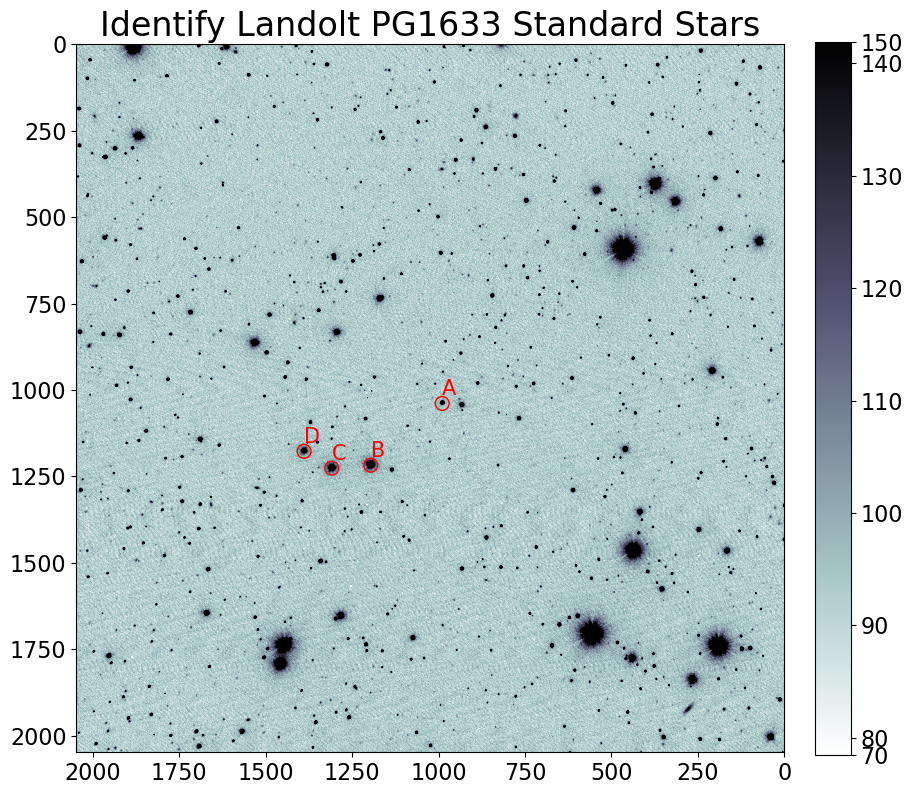

In [11]:
## Standard positions THEY MOVE AAAAAAAAAAA

#Group 1
Ax1 = 989.39458
Ay1 = 1038.9989

Bx1 = 1195.9784
By1 = 1217.6126

Cx1 = 1308.7005
Cy1 = 1226.2669

Dx1 = 1388.8106
Dy1 = 1177.4237

#Group 2
Ax2 = 982.64142
Ay2 = 1031.7099

Bx2 = 1189.4998
By2 = 1209.1895

Cx2 = 1301.8355
Cy2 = 1218.559

Dx2 = 1381.8664
Dy2 = 1169.9067

#Group 3
Ax3 = 894.54685
Ay3 = 1033.0178

Bx3 = 1101.2303
By3 = 1210.7703

Cx3 = 1213.8395
Cy3 = 1220.329

Dx3 = 1293.4832
Dy3 = 1171.6693

standard_positions_1 = [(Ax1,Ay1),(Bx1,By1),(Cx1,Cy1),(Dx1,Dy1)]
standard_positions_2 = [(Ax2,Ay2),(Bx2,By2),(Cx2,Cy2),(Dx2,Dy2)]
standard_positions_3 = [(Ax3,Ay3),(Bx3,By3),(Cx3,Cy3),(Dx3,Dy3)]

standard_aperture_1 = CircularAperture(standard_positions_1, r=20.0)
standard_aperture_2 = CircularAperture(standard_positions_2, r=20.0)
standard_aperture_3 = CircularAperture(standard_positions_3, r=20.0)

standard_annulus_1 = CircularAnnulus(standard_positions_1, r_in = 20, r_out = 25)
standard_annulus_2 = CircularAnnulus(standard_positions_2, r_in = 20, r_out = 25)
standard_annulus_3 = CircularAnnulus(standard_positions_3, r_in = 20, r_out = 25)


A_aperture = CircularAperture((Ax1,Ay1), r=20.0)
B_aperture = CircularAperture((Bx1,By1), r=20.0)
C_aperture = CircularAperture((Cx1,Cy1), r=20.0)
D_aperture = CircularAperture((Dx1,Dy1), r=20.0)

## Plot everything
show_image(PG_Grp1_R, cmap = "bone_r")
plt.xlim(2048, 0)
plt.ylim(2048, 0)
A_aperture.plot(color = 'Red')
B_aperture.plot(color = 'Red')
C_aperture.plot(color = 'Red')
D_aperture.plot(color = 'Red')
plt.annotate("A", (Ax1,Ay1-25),size = 15, color = "Red")
plt.annotate("B", (Bx1,By1-25),size = 15, color = "Red")
plt.annotate("C", (Cx1,Cy1-25),size = 15, color = "Red")
plt.annotate("D", (Dx1,Dy1-25),size = 15, color = "Red")
plt.title("Identify Landolt PG1633 Standard Stars")

Positions found by matching the (XY inverted) frame with figure on WIYN's website: https://wiyn.org/Observe/Landolt/charts/c109.html

4. Extract instrumental magnitudes for all of your standard stars using an approach that
you’ve advocated for as best you can in the questions above.

In [12]:
### Mag time yippeee
A_inst_mag_list = []
B_inst_mag_list = []
C_inst_mag_list = []
D_inst_mag_list = []

## Calc instrument mag
def instrument_mag(T, A, B):
    a_b = A * B
    tab = T - a_b
    m = -2.5 * np.log10(tab)
    return m

def aper_phot(dat, aper, annu):
    ## Aperture photometry
    standard_aper_phot_tab = aperture_photometry(dat, aper)
    standard_annu_phot_tab = aperture_photometry(dat, annu)
    annu_sum = standard_annu_phot_tab['aperture_sum']
    # Results Table
    aper_photometry_result = standard_aper_phot_tab
    aper_photometry_result['annulus_sum'] = annu_sum

    ## Area of the aperture
    aper_area = aper.area
    
    ## Calculate the mean background; annu_sum/annu_area
    annu_area = annu.area
    annu_sum_arr = np.array(annu_sum)
    annu_area_arr = np.array(annu_area)

    aper_photometry_result["mean_background"] = annu_sum_arr/annu_area_arr

    aper_photometry_result["instrument_mag"] = instrument_mag(aper_photometry_result["aperture_sum"], aper_area, aper_photometry_result["mean_background"])

    A_inst_mag_list.append(aper_photometry_result["instrument_mag"][0])
    B_inst_mag_list.append(aper_photometry_result["instrument_mag"][1])
    C_inst_mag_list.append(aper_photometry_result["instrument_mag"][2])
    D_inst_mag_list.append(aper_photometry_result["instrument_mag"][3])

In [13]:
aper_phot(PG_Grp1_U, standard_aperture_1, standard_annulus_1)
aper_phot(PG_Grp1_B, standard_aperture_1, standard_annulus_1)
aper_phot(PG_Grp1_R, standard_aperture_1, standard_annulus_1)
aper_phot(PG_Grp1_I, standard_aperture_1, standard_annulus_1)

aper_phot(PG_Grp2_U, standard_aperture_2, standard_annulus_2)
aper_phot(PG_Grp2_B, standard_aperture_2, standard_annulus_2)
aper_phot(PG_Grp2_R, standard_aperture_2, standard_annulus_2)
aper_phot(PG_Grp2_I, standard_aperture_2, standard_annulus_2)

aper_phot(PG_Grp3_U, standard_aperture_3, standard_annulus_3)
aper_phot(PG_Grp3_B, standard_aperture_1, standard_annulus_1)
aper_phot(PG_Grp3_R, standard_aperture_1, standard_annulus_1)
aper_phot(PG_Grp3_I, standard_aperture_1, standard_annulus_1)

/var/folders/nh/dfxkj5m51dg4sm8xg5_f8pc40000gp/T/ipykernel_16787/3616214110.py:11: RuntimeWarning: invalid value encountered in log10
  m = -2.5 * np.log10(tab)
/var/folders/nh/dfxkj5m51dg4sm8xg5_f8pc40000gp/T/ipykernel_16787/3616214110.py:11: RuntimeWarning: invalid value encountered in log10
  m = -2.5 * np.log10(tab)
/var/folders/nh/dfxkj5m51dg4sm8xg5_f8pc40000gp/T/ipykernel_16787/3616214110.py:11: RuntimeWarning: invalid value encountered in log10
  m = -2.5 * np.log10(tab)


In [14]:
A_inst_U = np.array([A_inst_mag_list[0], A_inst_mag_list[4], A_inst_mag_list[8]])
A_inst_B = np.array([A_inst_mag_list[1], A_inst_mag_list[5], A_inst_mag_list[9]])
A_inst_R = np.array([A_inst_mag_list[2], A_inst_mag_list[6], A_inst_mag_list[10]])
A_inst_I = np.array([A_inst_mag_list[3], A_inst_mag_list[7], A_inst_mag_list[11]])

B_inst_U = np.array([B_inst_mag_list[0], B_inst_mag_list[4], B_inst_mag_list[8]])
B_inst_B = np.array([B_inst_mag_list[1], B_inst_mag_list[5], B_inst_mag_list[9]])
B_inst_R = np.array([B_inst_mag_list[2], B_inst_mag_list[6], B_inst_mag_list[10]])
B_inst_I = np.array([B_inst_mag_list[3], B_inst_mag_list[7], B_inst_mag_list[11]])

C_inst_U = np.array([C_inst_mag_list[0], C_inst_mag_list[4], C_inst_mag_list[8]])
C_inst_B = np.array([C_inst_mag_list[1], C_inst_mag_list[5], C_inst_mag_list[9]])
C_inst_R = np.array([C_inst_mag_list[2], C_inst_mag_list[6], C_inst_mag_list[10]])
C_inst_I = np.array([C_inst_mag_list[3], C_inst_mag_list[7], C_inst_mag_list[11]])

D_inst_U = np.array([D_inst_mag_list[0], D_inst_mag_list[4], D_inst_mag_list[8]])
D_inst_B = np.array([D_inst_mag_list[1], D_inst_mag_list[5], D_inst_mag_list[9]])
D_inst_R = np.array([D_inst_mag_list[2], D_inst_mag_list[6], D_inst_mag_list[10]])
D_inst_I = np.array([D_inst_mag_list[3], D_inst_mag_list[7], D_inst_mag_list[11]])

5. Plot your standard star instrumental magnitudes versus their airmass (or since you have
many different standard stars taken at different airmass, plot the difference between the
accepted magnitude and your instrumental magnitude versus airmass). Use one of the
linear fitting routines in Python to do a least squares fit to find and plot the extinction
coefficients at each filter. You can find their magnitudes and colors in Landolt (1992).

In [ ]:
#IMG ids 211 -> 236 not being used because they are labeled "don't use for photom"
X_U = np.array([1.23, 1.49, 2.15])
X_B = np.array([1.24, 1.51, 2.19])
X_V = np.array([1.24, 1.52, 2.21])
X_R = np.array([1.24, 1.53, 2.23])
X_I = np.array([1.24, 1.53, 2.26])

fig, ax = plt.subplots(2,2, sharex = True)
ax[0,0].plot(X_U, A_inst_U, label = "Star A, U")
A_U_param, A_U_covariance = curve_fit(lin_model, X_U, A_inst_U)
A_U_m,A_U_b = A_U_param
print("Star A, U filter k = " + str(A_U_m))

ax[0,0].plot(X_B, A_inst_B, label = "Star A, B")
A_B_param, A_B_covariance = curve_fit(lin_model, X_B[:2], A_inst_B[:2]) #some values were strangely NaNs; exclude from calculation
A_B_m,A_B_b = A_B_param
print("Star A, B filter k = " + str(A_B_m))

ax[0,0].plot(X_R, A_inst_R, label = "Star A, R")
A_R_param, A_R_covariance = curve_fit(lin_model, X_R[:2], A_inst_R[:2])
A_R_m,A_R_b = A_R_param
print("Star A, R filter k = " + str(A_R_m))

ax[0,0].plot(X_I, A_inst_I, label = "Star A, I")
A_I_param, A_I_covariance = curve_fit(lin_model, X_I[:2], A_inst_I[:2])
A_I_m,A_I_b = A_I_param
print("Star A, I filter k = " + str(A_I_m))

ax[0,1].plot(X_U, B_inst_U, label = "Star B, U")
B_U_param, B_U_covariance = curve_fit(lin_model, X_U, B_inst_U)
B_U_m,B_U_b = B_U_param
print("Star B, U filter k = " + str(B_U_m))

ax[0,1].plot(X_B, B_inst_B, label = "Star B, B")
B_B_param, B_B_covariance = curve_fit(lin_model, X_B[:2], B_inst_B[:2])
B_B_m,B_B_b = B_B_param
print("Star B, B filter k = " + str(B_B_m))

ax[0,1].plot(X_R, B_inst_R, label = "Star B, R")
B_R_param, B_R_covariance = curve_fit(lin_model, X_R[:2], B_inst_R[:2])
B_R_m,B_R_b = B_R_param
print("Star B, R filter k = " + str(B_R_m))

ax[0,1].plot(X_I, B_inst_I, label = "Star B, I")
B_I_param, B_I_covariance = curve_fit(lin_model, X_I[:2], B_inst_I[:2])
B_I_m,B_I_b = B_I_param
print("Star B, I filter k = " + str(B_I_m))


ax[1,0].plot(X_U, C_inst_U, label = "Star C, U")
C_U_param, C_U_covariance = curve_fit(lin_model, X_U, C_inst_U)
C_U_m,C_U_b = C_U_param
print("Star C, U filter k = " + str(C_U_m))

ax[1,0].plot(X_B, C_inst_B, label = "Star C, B")
C_B_param, C_B_covariance = curve_fit(lin_model, X_B[:2], C_inst_B[:2])
C_B_m,C_U_b = C_B_param
print("Star C, B filter k = " + str(C_B_m))

ax[1,0].plot(X_R, C_inst_R, label = "Star C, R")
C_R_param, C_R_covariance = curve_fit(lin_model, X_R[:2], C_inst_R[:2])
C_R_m,C_R_b = C_R_param
print("Star C, R filter k = " + str(C_R_m))

ax[1,0].plot(X_I, C_inst_I, label = "Star C, I")
C_I_param, C_I_covariance = curve_fit(lin_model, X_I[:2], C_inst_I[:2])
C_I_m,C_I_b = C_I_param
print("Star C, I filter k = " + str(C_I_m))


ax[1,1].plot(X_U, D_inst_U, label = "Star D, U")
D_U_param, D_U_covariance = curve_fit(lin_model, X_U, D_inst_U)
D_U_m,D_U_b = D_U_param
print("Star D, U filter k = " + str(D_U_m))

ax[1,1].plot(X_B, D_inst_B, label = "Star D, B")
D_B_param, D_B_covariance = curve_fit(lin_model, X_B[:2], D_inst_B[:2])
D_B_m,D_B_b = D_B_param
print("Star D, B filter k = " + str(D_B_m))

ax[1,1].plot(X_R, D_inst_R, label = "Star D, R")
D_R_param, D_R_covariance = curve_fit(lin_model, X_R[:2], D_inst_R[:2])
D_R_m,D_R_b = D_R_param
print("Star D, R filter k = " + str(D_R_m))

ax[1,1].plot(X_I, D_inst_I, label = "Star D, I")
D_I_param, D_I_covariance = curve_fit(lin_model, X_I[:2], D_inst_I[:2])
D_I_m,D_U_b = D_I_param
print("Star D, I filter k = " + str(D_I_m))
fig.supxlabel("Airmass")
fig.supylabel("Instrumental Magnitude")
fig.tight_layout()

These plots are a little wacky, and my reduction pipeline for the V filter mysteriously fails for PG1633....I tried to debug that from HW4 and HW5 but I ran out of time to fully solve it. Instead, I am leaving out V from this calculation so I can still turn in a completed homework, but innacurate ks will definetly adversely affect my solutions going forward. So if things look wacky, this is why and my apologies. 

In [16]:
U_k = np.array([A_U_m, B_U_m, C_U_m, D_U_m])
U_k_avg = np.average(U_k)
B_k = np.array([A_B_m, B_B_m, C_B_m, D_B_m])
B_k_avg = np.average(B_k)
R_k = np.array([A_R_m, B_R_m, C_R_m, D_R_m])
R_k_avg = np.average(R_k)
I_k = np.array([A_I_m, B_I_m, C_I_m, D_I_m])
I_k_avg = np.average(I_k)

6. After extinction correcting your standard stars to zero airmasses (i.e., you’re correcting
to the top of the atmosphere), make a plot of the difference between real magnitudes and
instrumental magnitudes using your standard stars as a function of V−R color and B−V
color. Fit a linear relation to this trend. The fit gives you your instrumental zero points
and the first order color term which let you transform your instrumental photometry to
the standard system. Tabulate the instrumental zero point and first order color terms for
each band in a neat, digestible way.

In [17]:
#m0 = m - kX
U_A_m0 = np.average(A_inst_U[0]) - (U_k_avg*1.23)
B_A_m0 = np.average(A_inst_B[0]) - (B_k_avg*1.23)
R_A_m0 = np.average(A_inst_R[0]) - (R_k_avg*1.23)
I_A_m0 = np.average(A_inst_I[0]) - (I_k_avg*1.23)

U_B_m0 = np.average(B_inst_U[0]) - (U_k_avg*1.24)
B_B_m0 = np.average(B_inst_B[0]) - (B_k_avg*1.24)
R_B_m0 = np.average(B_inst_R[0]) - (R_k_avg*1.24)
I_B_m0 = np.average(B_inst_I[0]) - (I_k_avg*1.24)

U_C_m0 = np.average(C_inst_U[0]) - (U_k_avg*1.24)
B_C_m0 = np.average(C_inst_B[0]) - (B_k_avg*1.24)
R_C_m0 = np.average(C_inst_R[0]) - (R_k_avg*1.24)
I_C_m0 = np.average(C_inst_I[0]) - (I_k_avg*1.24)

U_D_m0 = np.average(D_inst_U[0]) - (U_k_avg*1.24)
B_D_m0 = np.average(D_inst_B[0]) - (B_k_avg*1.24)
R_D_m0 = np.average(D_inst_R[0]) - (R_k_avg*1.24)
I_D_m0 = np.average(D_inst_I[0]) - (I_k_avg*1.24)

In [19]:
## Standard mags from Landolt, Simbad
stan_U_A = 16.48
stan_U_B = 14.21
stan_U_C = 14.54
stan_U_D = 14.14

stan_B_A = 16.06
stan_B_B = 13.82
stan_B_C = 14.14
stan_B_D = 14.12

stan_R_A = 14.75
stan_R_B = 12.37
stan_R_C = 12.61
stan_R_D = 13.36

stan_I_A = 14.30
stan_I_B = 11.82
stan_I_C = 12.03
stan_I_D = 13.07

#Get inst mag - real mag for each star/filter
A_uU = U_A_m0 - stan_U_A
A_bB = B_A_m0 - stan_B_A
A_rR = R_A_m0 - stan_R_A
A_iI = I_A_m0 - stan_I_A
A_VR = 0.505 #Landolt 1992

B_uU = U_B_m0 - stan_U_B
B_bB = B_B_m0 - stan_B_B
B_rR = R_B_m0 - stan_R_B
B_iI = I_B_m0 - stan_I_B
B_VR = 0.590

C_uU = U_C_m0 - stan_U_C
C_bB = B_C_m0 - stan_B_C
C_rR = R_C_m0 - stan_R_C
C_iI = I_C_m0 - stan_I_C
C_VR = 0.618

D_uU = U_D_m0 - stan_U_D
D_bB = B_D_m0 - stan_B_D
D_rR = R_D_m0 - stan_R_D
D_iI = I_D_m0 - stan_I_D
D_VR = 0.324


uU_arr = np.array([A_uU, B_uU, C_uU, D_uU])
bB_arr = np.array([A_bB, B_bB, C_bB, D_bB])
rR_arr = np.array([A_rR, B_rR, C_rR, D_rR])
iI_arr = np.array([A_iI, B_iI, C_iI, D_iI])
VR_arr = np.array([A_VR, B_VR, C_VR, D_VR])

#Linear fits
uU_param, uU_covariance = curve_fit(lin_model, uU_arr, VR_arr)
uU_m,uU_b = uU_param
print("First order U color term = " + str(uU_m))
print("U zero point = " + str(uU_b))
bB_param, bB_covariance = curve_fit(lin_model, bB_arr, VR_arr)
bB_m,bB_b = bB_param
print("First order B color term = " + str(bB_m))
print("B zero point = " + str(bB_b))
rR_param, rR_covariance = curve_fit(lin_model, rR_arr, VR_arr)
rR_m,rR_b = rR_param
print("First order R color term = " + str(rR_m))
print("R zero point = " + str(rR_b))
iI_param, iI_covariance = curve_fit(lin_model, iI_arr, VR_arr)
iI_m,iI_b = iI_param
print("First order I color term = " + str(iI_m))
print("I zero point = " + str(iI_b))

First order U color term = 0.2187018907215838
U zero point = 6.357174878866949
First order B color term = 1.1908128444737704
B zero point = 34.58514974709754
First order R color term = 5.520038539479659
R zero point = 152.001955421119
First order I color term = 1.724710455784266
I zero point = 46.86997252929728


In [21]:
#Table lists
filter_name = ['U', 'B', 'R', 'I']
first_orders = [uU_m, bB_m, rR_m, iI_m]
zeros = [uU_b, bB_b, rR_b, iI_b]

#Table columns
filters = Table([filter_name])
color_terms = Table([first_orders])
zero_point = Table([zeros])

#Table!!
band_table = astropy.table.hstack([filters, color_terms, zeros])
band_table.rename_columns(['col0_1', 'col0_2', 'col0_3'], ['Filter', 'First Order Color Term', 'Zero Point'])
band_table

Filter,First Order Color Term,Zero Point
str1,float64,float64
U,0.2187018907215838,6.357174878866949
B,1.1908128444737704,34.58514974709754
R,5.520038539479659,152.001955421119
I,1.724710455784266,46.86997252929728


7. Using the extinction terms and color terms derived for the imaging dataset previously, do
photometry on the stars in NGC6823 and make a color magnitude diagram of this open
cluster. Either V vs. B−V or R vs. R−I are the most common ones you might find, but
there may be others in the literature and you are welcome to follow their lead.

In [23]:
#utilize in-class function for FWHM
plots=Imexamine() 
def get_imexam_fwhm(xcenter,ycenter,data):
    '''
    This function takes a position and image data and returns the fwhm that imexam would calculate.
    The inputs are the [xcenter,ycenter] position of the star and the image array of data.
    It runs imexam to return the azimuthally averaged flux and radius arrays. Then it imports imexam
    functions to adopt their sigma clipping and 1D Gaussian fit. The output is the fwhm of the 1D fit.

    This function was developed with help from ChatGPT.
    '''
    # you can extract the x and y values for the radial plot (but must set genplot=False)
    radius,flux = plots.radial_profile(xcenter,ycenter,data,genplot=False) 

    # match imexam's clipping setting
    sig_factor = plots.radial_profile_pars["sigma"][0] if plots.radial_profile_pars["clip"][0] else 0

    # fit the profile the same way imexam does for Gaussian1D
    fit = math_helper.fit_gauss_1d(radius,flux,sigma_factor=sig_factor,center_at=0,weighted=True)
    fwhm = math_helper.gfwhm(fit.stddev_0.value)[0]
    
    return fwhm

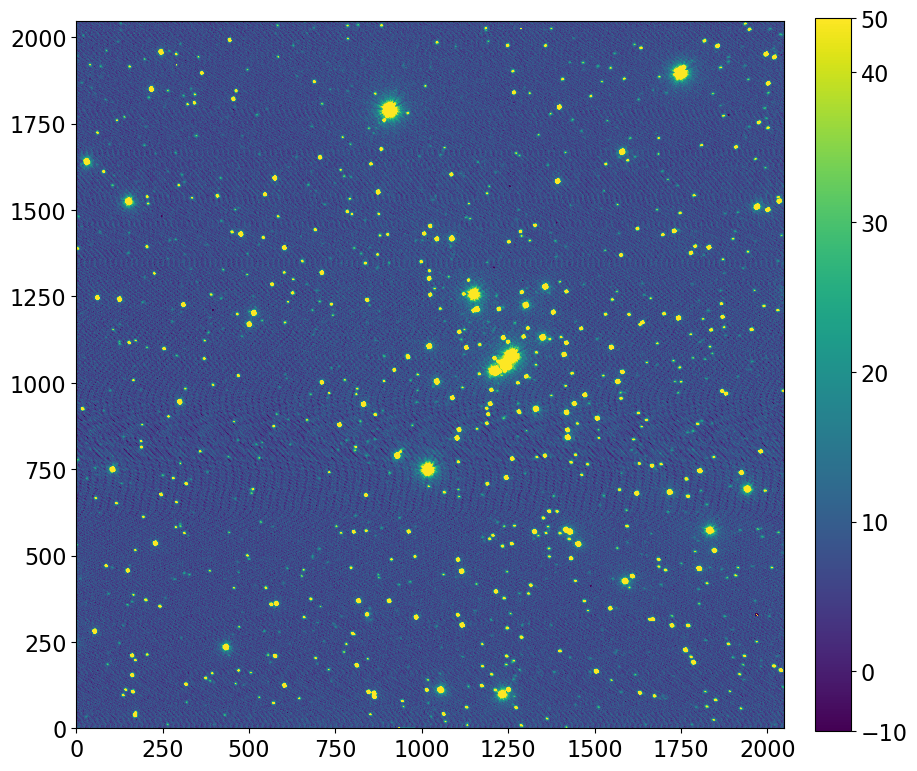

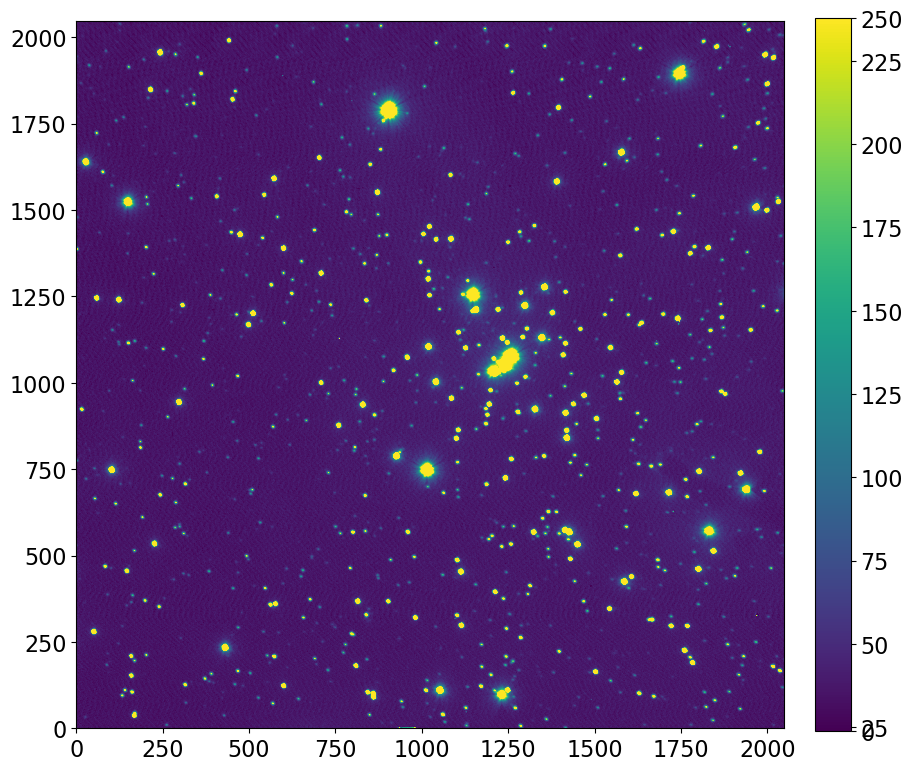

In [24]:
NGC_zot_glob = np.sort(glob.glob(NGC_data_dir+'*.fits'))
NGC_B = NGC_zot_glob[5] #B data
NGC_V = NGC_zot_glob[3] #Vdata
NGC_B_dat = fits.getdata(NGC_B)
NGC_V_dat = fits.getdata(NGC_V)
show_image(NGC_V_dat)
show_image(NGC_B_dat)

In [25]:
V_finder = photutils.detection.DAOStarFinder(threshold = 100, fwhm = get_imexam_fwhm(1020, 750,NGC_V_dat))
V_sources = V_finder(NGC_V_dat)
V_sources

x_pos = np.array(V_sources['xcentroid'])
y_pos = np.array(V_sources['ycentroid'])
positions = list(zip(x_pos, y_pos))

NGC_apers = CircularAperture(positions, r=15.0)
NGC_annus = CircularAnnulus(positions, r_in=20.0, r_out=25)

xc=1015.5316	yc=747.9427
Background per pixel: 78.56788616966327
Max. pix. flux = 41739.358
amp = 117810.529
fwhm =    10.463


/Applications/anaconda3/envs/astr8060/lib/python3.8/site-packages/imexam/math_helper.py:177: RuntimeWarning: invalid value encountered in log
  z = np.nan_to_num(np.log(flux))
/Applications/anaconda3/envs/astr8060/lib/python3.8/site-packages/imexam/math_helper.py:177: RuntimeWarning: invalid value encountered in log
  z = np.nan_to_num(np.log(flux))


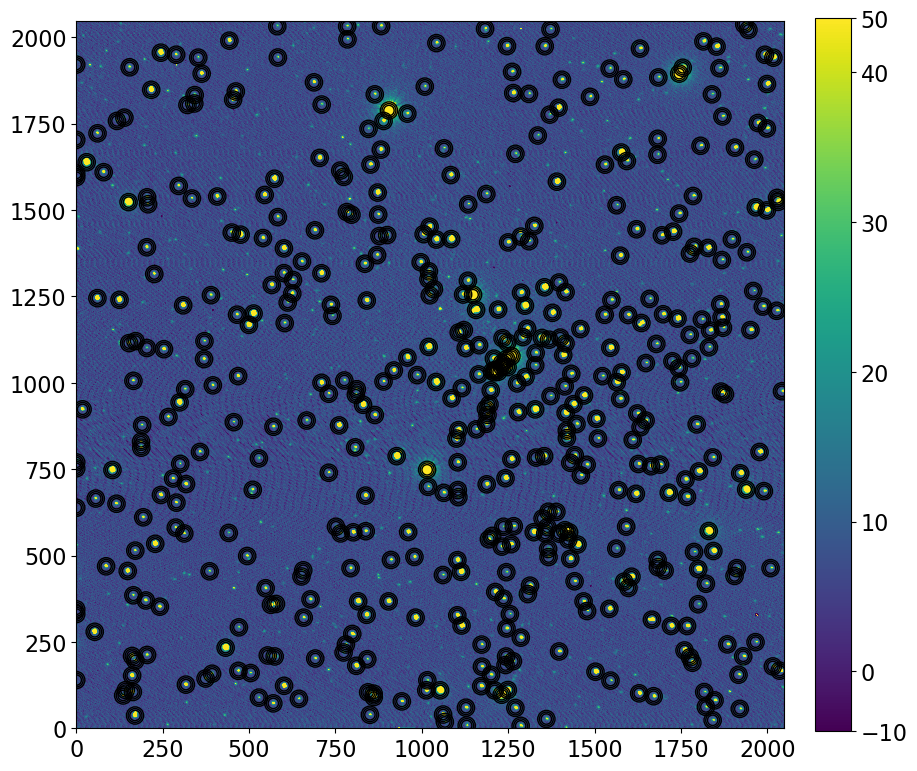

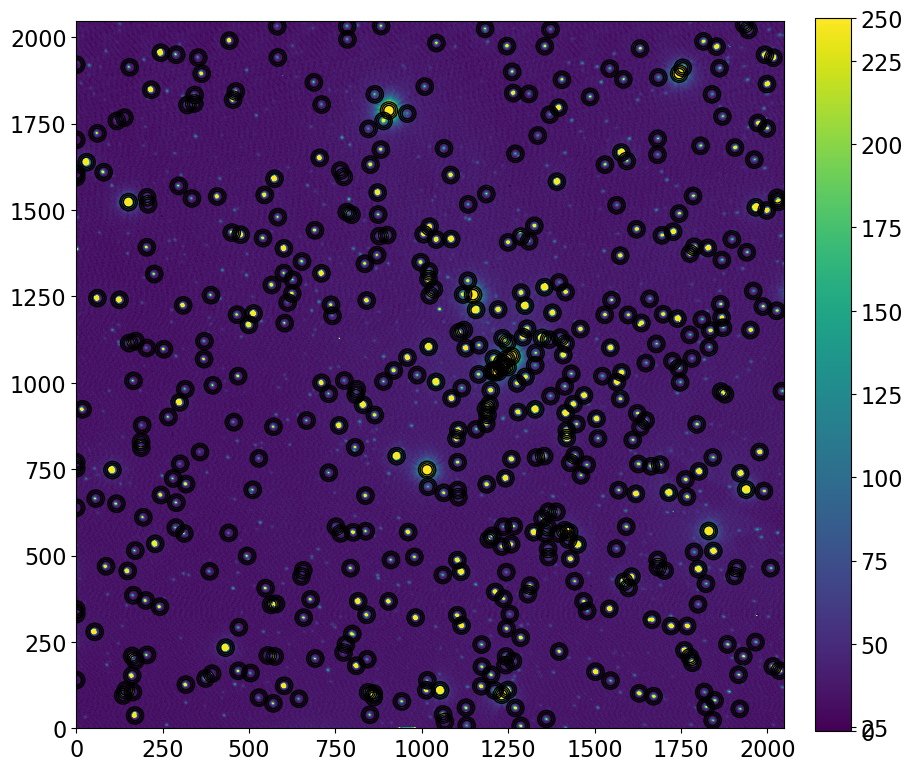

In [26]:
show_image(NGC_V_dat)
NGC_apers.plot()
NGC_annus.plot()

show_image(NGC_B_dat)
NGC_apers.plot()
NGC_annus.plot()

In [27]:
inst_mag_list = []
def get_phot(dat, aper, annu):
    ## Aperture photometry
    standard_aper_phot_tab = aperture_photometry(dat, aper)
    standard_annu_phot_tab = aperture_photometry(dat, annu)
    annu_sum = standard_annu_phot_tab['aperture_sum']
    # Results Table
    aper_photometry_result = standard_aper_phot_tab
    aper_photometry_result['annulus_sum'] = annu_sum

    ## Area of the aperture
    aper_area = aper.area
    
    ## Calculate the mean background; annu_sum/annu_area
    annu_area = annu.area
    annu_sum_arr = np.array(annu_sum)
    annu_area_arr = np.array(annu_area)

    aper_photometry_result["mean_background"] = annu_sum_arr/annu_area_arr

    aper_photometry_result["instrument_mag"] = instrument_mag(aper_photometry_result["aperture_sum"], aper_area, aper_photometry_result["mean_background"])
    inst_mag_list.append(np.array(aper_photometry_result["instrument_mag"]))
    #print(aper_photometry_result)
get_phot(NGC_B_dat, NGC_apers, NGC_annus)
b_inst_mag = inst_mag_list

Text(0.5, 1.0, 'NGC-6823 Color Magnitude Diagram')

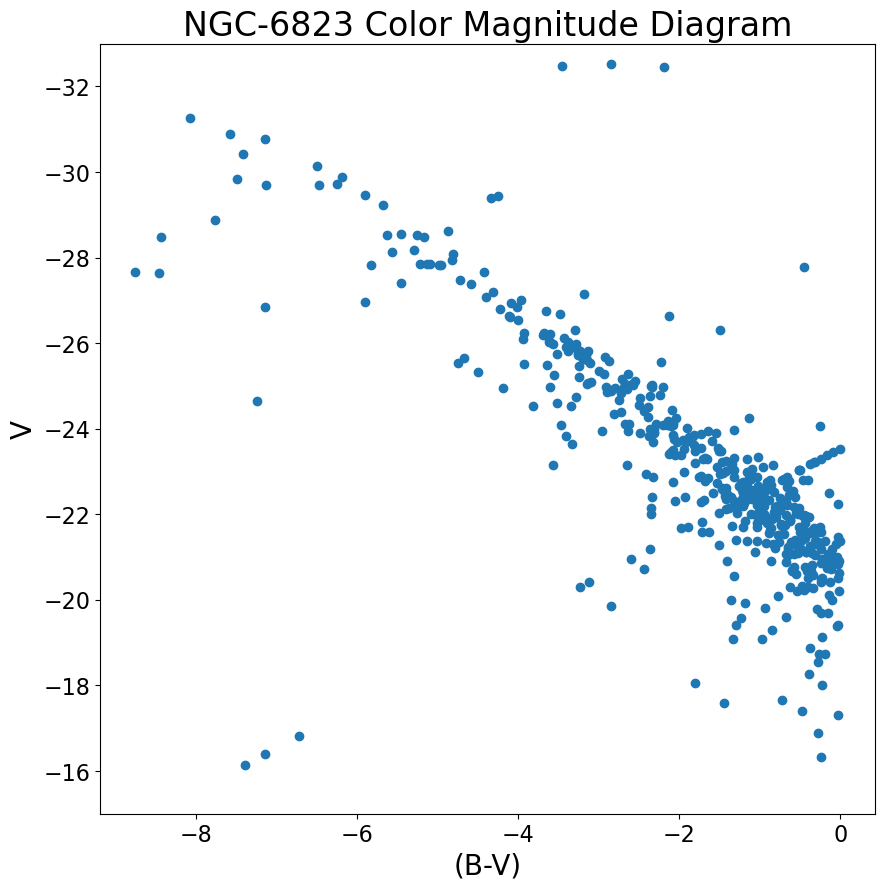

In [59]:
## Want B for (B-V); B = b0 + C0b
V = np.array(V_sources['mag'])
# b0 = b - kX
C0 = band_table['First Order Color Term'][1]
X_NGC_B = 1.09

b_inst_no_nan = np.nan_to_num(b_inst_mag, nan=-10.616) #replace NaNs with the median instrumental magnitude  
#b_inst_no_nan

B_NGC_m0 = b_inst_no_nan - (B_k_avg*X_NGC_B)
B = B_NGC_m0 + (C0*b_inst_no_nan)

plt.scatter(V, (B-V))
plt.ylim(-15, -33)
plt.xlabel("(B-V)")
plt.ylabel("V")
plt.title("NGC-6823 Color Magnitude Diagram")